In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install albumentations opencv-python

In [ ]:
input_folder = "/content/drive/MyDrive/dataset/genuine"
output_folder = "/content/drive/MyDrive/dataset_aug/genuine"

In [ ]:
import cv2
import os
import albumentations as A

transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=15, p=0.7),
    A.RandomBrightnessContrast(p=0.7),
    A.GaussianBlur(p=0.3),
    A.GaussNoise(p=0.3)
])

input_folder = "/content/drive/MyDrive/dataset_cv/Genuine"
output_folder = "/content/drive/MyDrive/dataset_aug/genuine"


In [ ]:
if not os.path.exists(input_folder):
    print(f"ERROR: Input folder not found at {input_folder}")
else:
    print("Input folder found. Starting augmentation...\n")

    # 🔹 Step 7: Loop through each medicine folder
    for med in os.listdir(input_folder):
        med_path = os.path.join(input_folder, med)

        if not os.path.isdir(med_path):
            continue  # skip files

        print(f"📁 Processing: {med}")

        # create output folder for this medicine
        os.makedirs(os.path.join(output_folder, med), exist_ok=True)

        # 🔹 Step 8: Loop through images inside medicine folder
        for img_name in os.listdir(med_path):
            img_path = os.path.join(med_path, img_name)

            # skip non-image files (.DS_Store etc.)
            if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue

            image = cv2.imread(img_path)

            if image is None:
                print(f"Skipping unreadable: {img_path}")
                continue

            # 🔹 Step 9: Generate augmented images
            for i in range(5):  # change to 7–10 if you want more data
                augmented = transform(image=image)['image']

                new_name = f"{os.path.splitext(img_name)[0]}_aug{i}.jpg"
                save_path = os.path.join(output_folder, med, new_name)

                cv2.imwrite(save_path, augmented)

        print(f"Done: {med}\n")

    print("AUGMENTATION COMPLETE!")

Input folder found. Starting augmentation...

📁 Processing: Azithral
Done: Azithral

📁 Processing: Allegra
Done: Allegra

📁 Processing: Combiflam
Done: Combiflam

📁 Processing: Montair
Done: Montair

📁 Processing: Ascoril
Done: Ascoril

📁 Processing: Zincovit
Done: Zincovit

📁 Processing: Corex
Done: Corex

📁 Processing: Benadryl
Done: Benadryl

📁 Processing: Dolo650
Done: Dolo650

📁 Processing: Evion400
Done: Evion400

📁 Processing: Cetrizine
Done: Cetrizine

📁 Processing: Pantafol DSR
Done: Pantafol DSR

📁 Processing: Crocin
Done: Crocin

📁 Processing: Calpol500
Done: Calpol500

📁 Processing: Becosules
Done: Becosules

📁 Processing: Amoxyclav
Done: Amoxyclav

AUGMENTATION COMPLETE!


In [ ]:
import cv2
import os
import numpy as np

input_folder = "/content/drive/MyDrive/dataset_aug/genuine"
output_folder = "/content/drive/MyDrive/dataset_aug/fake"

os.makedirs(output_folder, exist_ok=True)

if med.startswith('.') or med.lower() == "genuine":
    continue
for med in os.listdir(input_folder):
    med_path = os.path.join(input_folder, med)

    if not os.path.isdir(med_path):
        continue

    os.makedirs(os.path.join(output_folder, med), exist_ok=True)

    print(f"📁 Creating fake images for: {med}")

    for img_name in os.listdir(med_path):
        img_path = os.path.join(med_path, img_name)

        if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue

        image = cv2.imread(img_path)

        if image is None:
            continue

        h, w, _ = image.shape

        for i in range(3):  # create 3 fake versions per image
            fake = image.copy()

            # 🔹 1. Add noise
            noise = np.random.randint(0, 50, (h, w, 3), dtype='uint8')
            fake = cv2.add(fake, noise)

            # 🔹 2. Blur (simulate low quality)
            fake = cv2.GaussianBlur(fake, (7,7), 0)

            # 🔹 3. Random crop (simulate missing label)
            x = np.random.randint(0, w//4)
            y = np.random.randint(0, h//4)
            fake = fake[y:h, x:w]

            # 🔹 Resize back
            fake = cv2.resize(fake, (w, h))

            # 🔹 4. Change color tone
            fake = cv2.cvtColor(fake, cv2.COLOR_BGR2HSV)
            fake[:,:,1] = fake[:,:,1] * 0.7
            fake = cv2.cvtColor(fake, cv2.COLOR_HSV2BGR)

            save_path = os.path.join(output_folder, med, f"{img_name}_fake{i}.jpg")
            cv2.imwrite(save_path, fake)

    print(f"Done fake: {med}\n")

print("FAKE DATASET CREATED!")

📁 Creating fake images for: .DS_Store
Done fake: .DS_Store

📁 Creating fake images for: Genuine
Done fake: Genuine

📁 Creating fake images for: Azithral
Done fake: Azithral

📁 Creating fake images for: Allegra
Done fake: Allegra

📁 Creating fake images for: Combiflam
Done fake: Combiflam

📁 Creating fake images for: Montair
Done fake: Montair

📁 Creating fake images for: Ascoril
Done fake: Ascoril

📁 Creating fake images for: Zincovit
Done fake: Zincovit

📁 Creating fake images for: Corex
Done fake: Corex

📁 Creating fake images for: Benadryl
Done fake: Benadryl

📁 Creating fake images for: Dolo650
Done fake: Dolo650

📁 Creating fake images for: Evion400
Done fake: Evion400

📁 Creating fake images for: Cetrizine
Done fake: Cetrizine

📁 Creating fake images for: Pantafol DSR
Done fake: Pantafol DSR

📁 Creating fake images for: Crocin
Done fake: Crocin

📁 Creating fake images for: Calpol500
Done fake: Calpol500

📁 Creating fake images for: Becosules
Done fake: Becosules

📁 Creating fake 

In [ ]:
# 🔹 Install (run once)
!pip install pillow opencv-python

# 🔹 Imports
import os
import cv2
import random
from PIL import Image, ImageDraw, ImageFont

# 🔹 Paths
input_folder = "/content/drive/MyDrive/dataset_aug/genuine"
output_folder = "/content/drive/MyDrive/dataset_aug/fake_advanced"

os.makedirs(output_folder, exist_ok=True)

# 🔹 Load font (Colab default)
try:
    font = ImageFont.truetype("DejaVuSans-Bold.ttf", 40)
except:
    font = ImageFont.load_default()

# 🔹 Function to slightly modify medicine name
def modify_name(name):
    if len(name) > 3:
        i = random.randint(0, len(name)-1)
        return name[:i] + random.choice(['X','Z','0','@']) + name[i+1:]
    return name + "X"

# 🔹 Loop through medicines
for med in os.listdir(input_folder):

    # skip junk
    if med.startswith('.') or med.lower() == "genuine":
        continue

    med_path = os.path.join(input_folder, med)

    if not os.path.isdir(med_path):
        continue

    os.makedirs(os.path.join(output_folder, med), exist_ok=True)

    print(f"📁 Processing: {med}")

    for img_name in os.listdir(med_path):

        if not img_name.lower().endswith(('.jpg','.png','.jpeg')):
            continue

        img_path = os.path.join(med_path, img_name)

        image = cv2.imread(img_path)
        if image is None:
            continue

        h, w, _ = image.shape

        # ===============================
        # 🔴 1. TEXT TAMPERING (SPELLING + FONT)
        # ===============================
        pil_img = Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        draw = ImageDraw.Draw(pil_img)

        fake_name = modify_name(med)

        x = random.randint(10, w//2)
        y = random.randint(10, h//2)

        draw.text((x, y), fake_name, fill=(255, 0, 0), font=font)

        fake_text_img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

        cv2.imwrite(os.path.join(output_folder, med, f"{img_name}_text.jpg"), fake_text_img)


        # ===============================
        # 🔴 2. FAKE STICKER
        # ===============================
        sticker_img = image.copy()

        x1 = random.randint(0, w//2)
        y1 = random.randint(0, h//2)
        x2 = x1 + random.randint(50, 150)
        y2 = y1 + random.randint(30, 100)

        cv2.rectangle(sticker_img, (x1,y1), (x2,y2), (0,255,0), -1)

        cv2.putText(sticker_img, "SALE",
                    (x1+5, y1+30),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.8, (0,0,0), 2)

        cv2.imwrite(os.path.join(output_folder, med, f"{img_name}_sticker.jpg"), sticker_img)


        # ===============================
        # 🔴 3. REMOVE LABEL (BLACK PATCH)
        # ===============================
        removed_img = image.copy()

        x1 = random.randint(0, w//2)
        y1 = random.randint(0, h//2)
        x2 = x1 + random.randint(60, 200)
        y2 = y1 + random.randint(40, 150)

        cv2.rectangle(removed_img, (x1,y1), (x2,y2), (0,0,0), -1)

        cv2.imwrite(os.path.join(output_folder, med, f"{img_name}_removed.jpg"), removed_img)


        # ===============================
        # 🔴 4. FAKE LOGO OVERLAY
        # ===============================
        logo_img = image.copy()

        # create simple fake logo (colored box)
        logo_w, logo_h = 80, 40
        logo = np.zeros((logo_h, logo_w, 3), dtype=np.uint8)
        logo[:] = (255, 0, 0)  # blue box

        lx = random.randint(0, w - logo_w)
        ly = random.randint(0, h - logo_h)

        logo_img[ly:ly+logo_h, lx:lx+logo_w] = logo

        cv2.putText(logo_img, "FAKE",
                    (lx+5, ly+25),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5, (255,255,255), 1)

        cv2.imwrite(os.path.join(output_folder, med, f"{img_name}_logo.jpg"), logo_img)

    print(f"Done: {med}\n")

print("ADVANCED FAKE DATASET CREATED!")

📁 Processing: Azithral
Done: Azithral

📁 Processing: Allegra
Done: Allegra

📁 Processing: Combiflam
Done: Combiflam

📁 Processing: Montair
Done: Montair

📁 Processing: Ascoril
Done: Ascoril

📁 Processing: Zincovit
Done: Zincovit

📁 Processing: Corex
Done: Corex

📁 Processing: Benadryl
Done: Benadryl

📁 Processing: Dolo650
Done: Dolo650

📁 Processing: Evion400
Done: Evion400

📁 Processing: Cetrizine
Done: Cetrizine

📁 Processing: Pantafol DSR
Done: Pantafol DSR

📁 Processing: Crocin
Done: Crocin

📁 Processing: Calpol500
Done: Calpol500

📁 Processing: Becosules
Done: Becosules

📁 Processing: Amoxyclav
Done: Amoxyclav

ADVANCED FAKE DATASET CREATED!


SIAMESE PAIR CREATION

In [ ]:
!pip install torch torchvision

In [ ]:
import os
import random
from PIL import Image
import torch
from torch.utils.data import Dataset
import torchvision.transforms as transforms

In [ ]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

In [ ]:
class SiameseDataset(Dataset):
    def __init__(self, genuine_dir, fake_dir, transform=None):
        self.genuine_dir = genuine_dir
        self.fake_dir = fake_dir
        self.transform = transform

        self.meds = os.listdir(genuine_dir)

        self.data = []

        for med in self.meds:
            g_path = os.path.join(genuine_dir, med)
            f_path = os.path.join(fake_dir, med)

            if not os.path.isdir(g_path) or not os.path.isdir(f_path):
                continue

            g_images = [os.path.join(g_path, img) for img in os.listdir(g_path) if img.endswith(('.jpg','.png','.jpeg'))]
            f_images = [os.path.join(f_path, img) for img in os.listdir(f_path) if img.endswith(('.jpg','.png','.jpeg'))]

            # Genuine pairs (label = 1)
            for i in range(min(10, len(g_images))):
                for j in range(i+1, min(10, len(g_images))):
                  self.data.append((g_images[i], g_images[j], 1))

            # Fake pairs (label = 0)
            for g in g_images[:10]:
              f = random.choice(f_images)
              self.data.append((g, f, 0))
    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img1_path, img2_path, label = self.data[idx]

        img1 = Image.open(img1_path).convert("RGB")
        img2 = Image.open(img2_path).convert("RGB")

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, torch.tensor(label, dtype=torch.float32)

In [ ]:
import os

genuine_path = "/content/drive/MyDrive/dataset_aug/genuine"
fake_path = "/content/drive/MyDrive/dataset_aug/fake_advanced"

# Check if paths exist before creating the dataset
if not os.path.exists(genuine_path):
    print(f"ERROR: Genuine dataset folder not found at {genuine_path}")
elif not os.path.exists(fake_path):
    print(f"ERROR: Fake dataset folder not found at {fake_path}")
else:
    print("Both genuine and fake dataset folders found. Creating Siamese dataset...")
    dataset = SiameseDataset(genuine_path, fake_path, transform)
    print(f"Siamese dataset created with {len(dataset)} pairs.")

Both genuine and fake dataset folders found. Creating Siamese dataset...
Siamese dataset created with 880 pairs.


In [ ]:
from torch.utils.data import DataLoader

dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

In [ ]:
img1, img2, label = dataset[0]

print(img1.shape, img2.shape, label)

torch.Size([3, 128, 128]) torch.Size([3, 128, 128]) tensor(1.)


BUILD SIAMESE NETWORK + TRAINING

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

In [ ]:
class SiameseNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = models.resnet18(pretrained=True)
        self.backbone.fc = nn.Linear(512, 128)

    def forward_once(self, x):
        return self.backbone(x)

    def forward(self, x1, x2):
        out1 = self.forward_once(x1)
        out2 = self.forward_once(x2)
        return out1, out2

In [ ]:
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, out1, out2, label):
        distance = torch.sqrt(torch.sum((out1 - out2)**2, dim=1))
        loss = torch.mean((1-label)*distance**2 + label*(torch.clamp(self.margin - distance, min=0))**2)
        return loss

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SiameseNetwork().to(device)
criterion = ContrastiveLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 197MB/s]


In [ ]:
epochs = 5

for epoch in range(epochs):
    total_loss = 0

    for img1, img2, label in dataloader:
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)

        out1, out2 = model(img1, img2)

        loss = criterion(out1, out2, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 21.2485
Epoch 2, Loss: 14.1628
Epoch 3, Loss: 10.1282
Epoch 4, Loss: 9.7648
Epoch 5, Loss: 9.7104


In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/siamese_model.pth")

In [ ]:
def predict(img1, img2):
    model.eval()

    with torch.no_grad():
        img1 = img1.unsqueeze(0).to(device)
        img2 = img2.unsqueeze(0).to(device)

        out1, out2 = model(img1, img2)

        distance = torch.sqrt(torch.sum((out1 - out2)**2, dim=1))

        return distance.item()

EVALUATION

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

y_true = []
all_distances = []

model.eval()

with torch.no_grad():
    for img1, img2, label in dataloader:
        img1, img2 = img1.to(device), img2.to(device)

        out1, out2 = model(img1, img2)

        distance = torch.sqrt(torch.sum((out1 - out2)**2, dim=1))

        # store values
        all_distances.extend(distance.cpu().numpy())
        y_true.extend(label.numpy())


# 🔥 NOW TEST DIFFERENT THRESHOLDS HERE
import numpy as np

for t in [0.5, 0.7, 1.0, 1.5]:
    preds = (np.array(all_distances) < t).astype(int)

    print(f"\n🔹 Threshold: {t}")
    print("Accuracy:", accuracy_score(y_true, preds))
    print("Precision:", precision_score(y_true, preds))
    print("Recall:", recall_score(y_true, preds))
    print("F1 Score:", f1_score(y_true, preds))
    print("Confusion Matrix:\n", confusion_matrix(y_true, preds))


🔹 Threshold: 0.5
Accuracy: 0.19318181818181818
Precision: 0.75
Recall: 0.020833333333333332
F1 Score: 0.04054054054054054
Confusion Matrix:
 [[155   5]
 [705  15]]

🔹 Threshold: 0.7
Accuracy: 0.19090909090909092
Precision: 0.5235294117647059
Recall: 0.12361111111111112
F1 Score: 0.2
Confusion Matrix:
 [[ 79  81]
 [631  89]]

🔹 Threshold: 1.0
Accuracy: 0.5397727272727273
Precision: 0.762063227953411
Recall: 0.6361111111111111
F1 Score: 0.6934140802422407
Confusion Matrix:
 [[ 17 143]
 [262 458]]

🔹 Threshold: 1.5
Accuracy: 0.7693181818181818
Precision: 0.8125755743651754
Recall: 0.9333333333333333
F1 Score: 0.8687782805429864
Confusion Matrix:
 [[  5 155]
 [ 48 672]]


RESULT GRAPHS

1.Loss Graph


In [ ]:
losses = []

for epoch in range(epochs):
    total_loss = 0

    for img1, img2, label in dataloader:
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)

        out1, out2 = model(img1, img2)
        loss = criterion(out1, out2, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    losses.append(total_loss)
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 8.0732
Epoch 2, Loss: 6.5011
Epoch 3, Loss: 5.7113
Epoch 4, Loss: 5.2795
Epoch 5, Loss: 4.8997


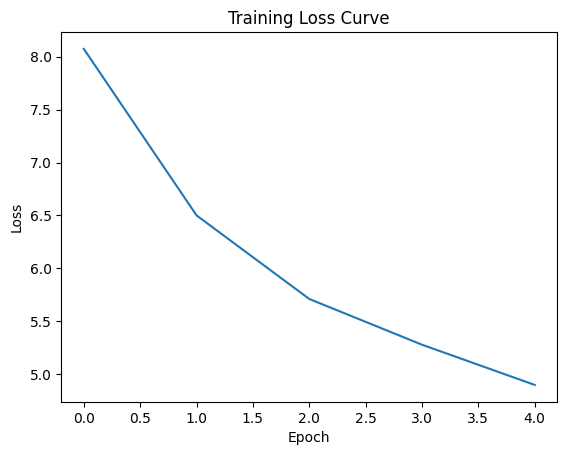

In [ ]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

2. Confusion Matrix Graph

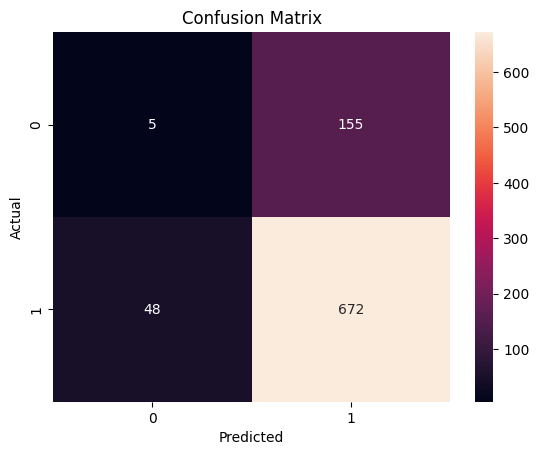

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, preds)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


5	Correct fake detection (True Negative)
155	Fake wrongly classified as genuine
48	Genuine wrongly classified as fake
672	Correct genuine detection (True Positive)